This notebook is to develop code for a case study for an undisclosed company in Adtech
- Date: July 21st, 2026

You are tasked with preparing a presentation for a long-time client, Agency XYZ, regarding a recent digital ad campaign for City XYZ. You will need to cover:
 - Programmatic Ad-Tech Landscape: An overview of the programmatic space, key players, and [REDACTED]’s value as a Demand-Side Platform.
 - Campaign Analysis: A data-driven review of campaign performance, including insights on what is working and recommendations for future strategies. Please perform your analysis using SQL or Python and include your documented code as part of the submission.
 - Product Strategy & Critical Thinking: Strategic considerations regarding a travel-specific identity data graph, including potential data sources, use cases for targeting and measurement, and risk mitigation strategies.


Expectations & Evaluation
We are looking to see how you approach problems and your ability to turn complex data and concepts into clear, actionable insights. We will be evaluating your submission on the following criteria:
 - Communication: Your ability to synthesize complex concepts into easy-to-understand terms.
 - Technical & Strategic Depth: For the ad-tech section, we look for a depth of industry analysis that goes beyond a surface-level understanding. For the campaign analysis, we assess your technical data capabilities and the quality of your business insights.
 - Innovative Thinking: Your ability to align feature recommendations with macro/industry trends and provide thoughtful risk mitigation strategies.


Submission Guidelines
 - Format: Please provide a summary presentation (maximum 6 slides, excluding cover page/appendices). 
 - Code Submission: As part of your campaign analysis, please include your documented SQL or Python code. We want to see the logic and technical steps you took to arrive at your insights.



# Setup
## Requirements, Imports

In [1]:
!pip install -r ../requirements.txt
# this installs the following: 
    # pandas
    # matplotlib
    # numpy
    # seaborn
    # scipy
    # scikit-learn
    # openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import sklearn
import seaborn as sns
import scipy
from scipy import stats

## Load in data

In [3]:
visitationFTA = pd.read_excel("../data/CityXYZ_visitationFTA_data_March.xlsx")
visitationFTA.head()
# note: FTA = Foot Traffic Attribution. This dataset shows real customers that came into a store, and how we can attribute their visit!

,Visit,Advertiser ID,User Profile ID,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Location Type,Visited ZIP,New Visit,Attributed Visit,...,Demo HHI,Origin_Country,Origin_Region,Origin_DMA,Origin_City,Origin_Zipcode,Visit Date,Campaign Name,Creative Name,Group
0,1,1234,07502db2-a8cb-4c1d-9ddf-9a47f75ea747,1276102952747384832,1743187567,0.952575,Attractions,89052,0,True,...,$100-$150K,us,nv,839,henderson,89044,28/03/2025,AgencyXYZ_Display_Travel AI _CompetitorConques...,484343_V1_160x600_SB_44099_Las_City XYZ,Exposed
1,2,1234,a62bf21b-bdb2-4b25-977c-2492a2ed9f34,1276102959519739904,1742764148,0.952222,Retail,89141,0,True,...,$75-100K,us,fl,528,ft lauderdale,33322,23/03/2025,AgencyXYZ_Native_Travel AI_City XYZ Not Booked,BRL - 1200x627,Exposed
2,3,1234,238a7097-5f88-4758-a526-298d9d7730b9,1276102959519739904,1742068105,0.950136,Retail,89141,0,True,...,$100-$150K,us,ok,671,bixby,74008,15/03/2025,AgencyXYZ_Native_Travel AI_City XYZ Booked,BRL - 1200x627,Exposed
3,4,1234,43f649f7-8859-4d16-a2fc-644db8feb5ef,699463065495220224,1743195529,0.948397,Attractions,89124,1,True,...,$75-100K,us,mi,505,new baltimore,48047,28/03/2025,AgencyXYZ_Native_Travel AI_City XYZ Booked,NMC1 Homepage - 800x600,Exposed
4,5,1234,84b3fff2-8400-412b-a75b-cdc7be607260,699463065495220224,1743026081,0.948396,Attractions,89124,1,True,...,$100-$150K,us,ca,862,orangevale,95662,26/03/2025,AgencyXYZ_Display_Travel AI _CompetitorConques...,484343_V1_728x90_SB_44099_Las_City XYZ,Exposed


In [4]:
campaign_metrics = pd.read_excel("../data/CityXYZ_CampaignMetrics_March.xlsx")
campaign_metrics.head()

,Advertiser ID,Advertiser,Campaign Group ID,Campaign Group,Campaign ID,Campaign,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Creative ID,Creative,Creative Size,Channel Type,Channel Subtype,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546648,NMC1 Homepage - 1200x627,1200x627,Native,Standard,610.64,79370,45,7.69,0.0006,13.57
1,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546649,NMC1 Homepage - 600x600,600x600,Native,Standard,65.83,8308,4,7.92,0.0005,16.46
2,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546650,NMC1 Homepage - 800x600,800x600,Native,Standard,24.83,3256,0,7.63,0.0000,0.00
3,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546651,BRL - 1200x627,1200x627,Native,Standard,393.53,51281,27,7.67,0.0005,14.58
4,1234,Agency XYZ,339812,AgencyXYZ,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546652,BRL - 600x600,600x600,Native,Standard,75.31,9557,4,7.88,0.0004,18.83


In [5]:
dataframe_names = {
    "Visitation FTA"    : visitationFTA,
    "Campaign Metrics"  : campaign_metrics,
}
for name, dataframe in dataframe_names.items():
    print(f"\nFor the dataset {name}, here is the info:")
    dataframe.info()


For the dataset Visitation FTA, here is the info:
<class 'pandas.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Visit                  2303 non-null   int64  
 1   Advertiser ID          2303 non-null   int64  
 2   User Profile ID        2303 non-null   str    
 3   Spatial Location ID    2303 non-null   int64  
 4   Visit Time Stamp       2303 non-null   int64  
 5   Visit Attribute Score  2303 non-null   float64
 6   Location Type          2303 non-null   str    
 7   Visited ZIP            2303 non-null   int64  
 8   New Visit              2303 non-null   int64  
 9   Attributed Visit       2303 non-null   bool   
 10  Campaign ID            2303 non-null   int64  
 11  Creative ID            2303 non-null   int64  
 12  Auction ID             2303 non-null   str    
 13  First Impression Date  2303 non-null   str    
 14  Device Type     

In [6]:
visitationFTA.describe()

,Visit,Advertiser ID,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Visited ZIP,New Visit,Campaign ID,Creative ID,Total Impressions,Origin_DMA
count,2303.000000,2303.0,2.303000e+03,2.303000e+03,2303.000000,2303.000000,2303.000000,2.303000e+03,2.303000e+03,2303.000000,2303.000000
mean,1152.000000,1234.0,4.258054e+17,1.742814e+09,0.915715,89109.283543,0.649153,2.244842e+06,9.546698e+06,7.328267,713.461138
std,664.963157,0.0,3.436973e+17,4.400115e+05,0.001618,8.715850,0.477339,2.872344e+01,2.672137e+01,19.248138,119.554651
min,1.000000,1234.0,1.229956e+17,1.741686e+09,0.915618,89014.000000,0.000000,2.244711e+06,9.546648e+06,1.000000,0.000000
25%,576.500000,1234.0,1.231836e+17,1.742500e+09,0.915628,89109.000000,0.000000,2.244830e+06,9.546678e+06,1.500000,613.000000
50%,1152.000000,1234.0,1.231844e+17,1.742871e+09,0.915633,89109.000000,1.000000,2.244857e+06,9.546690e+06,3.000000,753.000000
75%,1727.500000,1234.0,6.996451e+17,1.743187e+09,0.915650,89109.000000,1.000000,2.244861e+06,9.546724e+06,8.000000,807.000000
max,2303.000000,1234.0,1.276106e+18,1.743465e+09,0.952575,89169.000000,1.000000,2.244863e+06,9.546744e+06,494.000000,881.000000


In [7]:
campaign_metrics.describe()

,Advertiser ID,Campaign Group ID,Campaign ID,Creative ID,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
count,120.0,120.0,1.200000e+02,1.200000e+02,120.000000,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,1234.0,339812.0,2.244833e+06,9.599958e+06,833.335917,1.598628e+05,288.075000,5.944667,0.001622,9.608417
std,0.0,0.0,3.395613e+01,1.077439e+05,1424.737128,2.975639e+05,600.932387,1.302939,0.002317,12.823191
min,1234.0,339812.0,2.244711e+06,9.546648e+06,0.220000,3.100000e+01,0.000000,3.900000,0.000000,0.000000
25%,1234.0,339812.0,2.244829e+06,9.546678e+06,71.157500,1.021800e+04,6.500000,4.955000,0.000400,2.205000
50%,1234.0,339812.0,2.244832e+06,9.546708e+06,266.990000,4.747600e+04,36.000000,6.005000,0.001300,3.485000
75%,1234.0,339812.0,2.244858e+06,9.546738e+06,889.840000,1.566270e+05,273.000000,7.047500,0.002100,12.310000
max,1234.0,339812.0,2.244863e+06,9.877153e+06,6620.860000,1.618553e+06,3070.000000,9.740000,0.017600,73.040000


# Preprocess Data
## Data cleaning
### Null values

In [8]:
# As seen above in the .info prints, both datasets have no nulls, but to check this, I like to visualize with a heatmap.
# Here, any null values in the datasets would be colored differently than red, but they are all the same, showing no null data:

<Axes: >

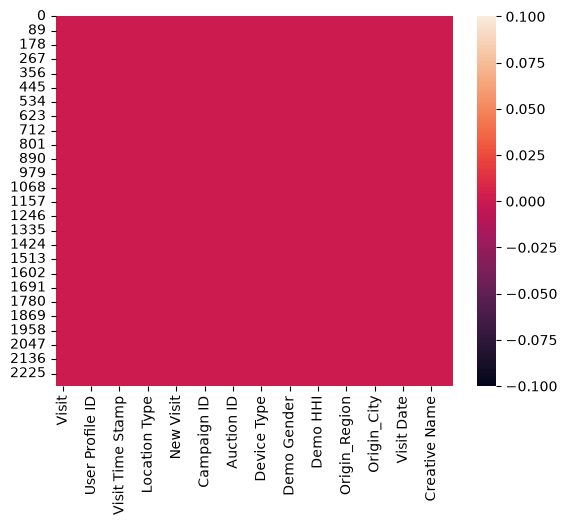

In [9]:
sns.heatmap(visitationFTA.isnull())

<Axes: >

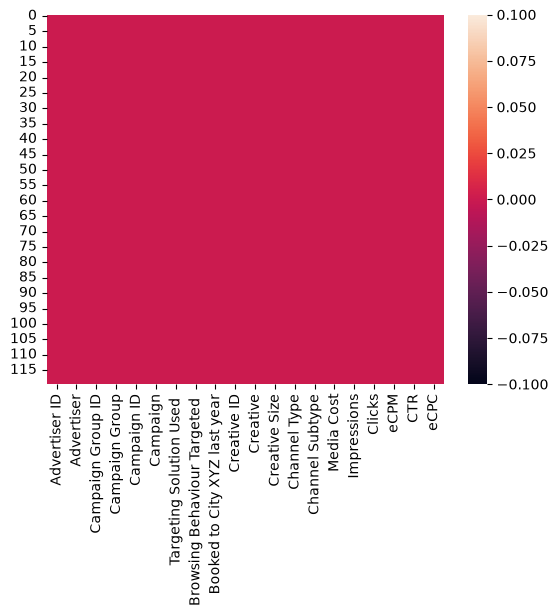

In [10]:
sns.heatmap(campaign_metrics.isnull())

### Duplicates

In [11]:
for df in [visitationFTA, campaign_metrics]:
    numBefore = df.shape[0]
    df.drop_duplicates()
    print(f"Cleaned from {numBefore} to {df.shape[0]} rows.")

Cleaned from 2303 to 2303 rows.
Cleaned from 120 to 120 rows.


In [12]:
# so there aren't any clear duplicates, but there still might be data with the same key column ID, that is duplicated.
# By looking at the dfs, I see that:
    # visitationFTA 's key column is "Visit". and this is a unique identifier from 1 to 2303
    # campaign_metrics 's key column is "Creative ID". and this is a unique identifier from 9546648 to 9877153
        # Note, finding the keyCol for campaign_metrics was more involved:

# campaign_metrics['Advertiser ID'].value_counts()   # 1 unique value = all are identical, this column can be removed from this current analysis with no impact!
# campaign_metrics['Campaign ID'].value_counts()     # 16 unique values, not a keyCol
campaign_metrics['Creative ID'].value_counts()       # 120 unique values, this is the key idenitfier!
# campaign_metrics.head()

Creative ID
9546648    1
9546649    1
9546650    1
9546651    1
9546652    1
          ..
9800187    1
9877150    1
9877151    1
9877152    1
9877153    1
Name: count, Length: 120, dtype: int64

In [13]:
# visitationFTA.set_index('Visit', inplace = True)
# visitationFTA.head(1)

In [14]:
# campaign_metrics.set_index('Creative ID', inplace = True)
# campaign_metrics.head(1)

### Remove Static Columns
- To tidy up, we can remove columns that are entirely the same throughout the df. For example, I saw this:
- `campaign_metrics['Advertiser ID'].value_counts()` = 1 unique value 
- This means that the whole column is identical, this column can be removed from this current analysis with no impact!


In [15]:
def removeStaticCols (df, title):
    print (f"For dataframe {title}")
    retDf = df.copy()
    for col in retDf.columns:
        if retDf[col].nunique() == 1:
                    print(f"   Dropping '{col}' - only 1 unique value: {retDf[col].iloc[0]}")
                    retDf = retDf.drop(columns=[col])
    return retDf

visitationFTA = removeStaticCols(visitationFTA, "Visitation FTA")
campaign_metrics = removeStaticCols(campaign_metrics, "Campaign Metrics")
print(f"   No columns have been dropped.")


For dataframe Visitation FTA
   Dropping 'Advertiser ID' - only 1 unique value: 1234
   Dropping 'Attributed Visit' - only 1 unique value: True
   Dropping 'Origin_Country' - only 1 unique value: us
   Dropping 'Group' - only 1 unique value: Exposed
For dataframe Campaign Metrics
   Dropping 'Advertiser ID' - only 1 unique value: 1234
   Dropping 'Advertiser' - only 1 unique value: Agency XYZ
   Dropping 'Campaign Group ID' - only 1 unique value: 339812
   Dropping 'Campaign Group' - only 1 unique value: AgencyXYZ
   Dropping 'Channel Subtype' - only 1 unique value: Standard
   No columns have been dropped.


### Check Data Logic
#### Checking non-negatives
 - Some data can never be negative, like spend, or inventory, so I have to check this:

In [16]:
visitationFTA.columns

Index(['Visit', 'User Profile ID', 'Spatial Location ID', 'Visit Time Stamp',
       'Visit Attribute Score', 'Location Type', 'Visited ZIP', 'New Visit',
       'Campaign ID', 'Creative ID', 'Auction ID', 'First Impression Date',
       'Device Type', 'Total Impressions', 'Demo Gender', 'Demo Age',
       'Demo HHI', 'Origin_Region', 'Origin_DMA', 'Origin_City',
       'Origin_Zipcode', 'Visit Date', 'Campaign Name', 'Creative Name'],
      dtype='str')

In [17]:
visitationNumericCols = visitationFTA.select_dtypes(include="number")
visitationNumericCols.head(1)

,Visit,Spatial Location ID,Visit Time Stamp,Visit Attribute Score,Visited ZIP,New Visit,Campaign ID,Creative ID,Total Impressions,Origin_DMA
0,1,1276102952747384832,1743187567,0.952575,89052,0,2244831,9546733,1,839


In [18]:
listNonNegativeVisitation = ['Total Impressions']

In [19]:
campaign_metrics.columns

Index(['Campaign ID', 'Campaign', 'Targeting Solution Used ',
       'Browsing Behaviour Targeted ', 'Booked to City XYZ last year',
       'Creative ID', 'Creative', 'Creative Size', 'Channel Type',
       'Media Cost', 'Impressions', 'Clicks', 'eCPM', 'CTR', 'eCPC'],
      dtype='str')

In [20]:
campaignNumericCols = campaign_metrics.select_dtypes(include="number")
campaignNumericCols.head(1)

,Campaign ID,Creative ID,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,2244856,9546648,610.64,79370,45,7.69,0.0006,13.57


In [21]:
listNonNegativeCampaign = ['Media Cost', 'Impressions', 'Clicks', 'eCPM', 'CTR', 'eCPC']

In [22]:
def checkNegativeVisitation (df):
    retDf = df.copy()
    for col in listNonNegativeVisitation:
        negative_rows = df.loc[df[col] < 0]
        print(f"# of negative rows in Visitation FTA dataset:{negative_rows.shape[0]}")

checkNegativeVisitation(visitationFTA)

def checkNegativeCampaign (df):
    retDf = df.copy()
    for col in listNonNegativeCampaign:
        negative_rows = df.loc[df[col] < 0]
        print(f"# of negative rows in Campaign Metrics dataset:{negative_rows.shape[0]}")

checkNegativeCampaign(campaign_metrics)


# of negative rows in Visitation FTA dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0
# of negative rows in Campaign Metrics dataset:0


- note, this code was not optimal, but it works, and shows no negative values.

#### Checking Categorical data


In [23]:
campaign_metrics.head(2)

,Campaign ID,Campaign,Targeting Solution Used,Browsing Behaviour Targeted,Booked to City XYZ last year,Creative ID,Creative,Creative Size,Channel Type,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546648,NMC1 Homepage - 1200x627,1200x627,Native,610.64,79370,45,7.69,0.0006,13.57
1,2244856,AgencyXYZ_Native_PCAI _City XYZ Booked,PCAI,City XYZ interest,Booked,9546649,NMC1 Homepage - 600x600,600x600,Native,65.83,8308,4,7.92,0.0005,16.46


#### Checking calculated values
- CPC: Cost per Click = Spend/Click
- eCPM: effective Cost per Mille (1000) = 1000*Spend/Impressions
- CTR: Clickthrough Rate = Clicks/Impressions
- eCPC: effective Cost per Click = total earning/total clicks

In [24]:
checking_metrics = campaign_metrics.copy()
colsToSkip = ['Media Cost','Impressions','Clicks','eCPM','CTR','eCPC']
for col in checking_metrics.columns:
    if col in colsToSkip: 
        pass
    else: 
        del checking_metrics[col]
checking_metrics.head(1)

,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC
0,610.64,79370,45,7.69,0.0006,13.57


In [25]:
checking_metrics['Calculated eCPM'] = (checking_metrics['Media Cost'] / checking_metrics['Impressions'] * 1000).round(2)
checking_metrics['Calculated CTR'] = (checking_metrics['Clicks'] / checking_metrics['Impressions']).round(4)
checking_metrics['Calculated eCPC'] = (checking_metrics['Media Cost'] / checking_metrics['Clicks']).round(2)

checking_metrics.head(1)

,Media Cost,Impressions,Clicks,eCPM,CTR,eCPC,Calculated eCPM,Calculated CTR,Calculated eCPC
0,610.64,79370,45,7.69,0.0006,13.57,7.69,0.0006,13.57


In [33]:
def checkCalculatedMetrics(df):
    retDf = df.copy()
    for col in ['eCPM', 'CTR', 'eCPC']:
        calc_col = 'Calculated ' + col
        abs_diff = np.abs(retDf[col] - retDf[calc_col])
        sum_abs_diff = abs_diff.sum()
        scale = np.abs(retDf[calc_col]).replace(0, np.nan)
        pct_off = (abs_diff / scale).replace([np.inf, -np.inf], np.nan)
        avg_pct_off = pct_off.mean(skipna=True) * 100
        print(f"- {col}:\tSum of differences = {sum_abs_diff:.4f}, Average % off = {avg_pct_off:.4f}%")
        if pct_off.isna().any():
            print(f"   Note: {pct_off.isna().sum()} rows had zero/undefined calculated {col}")

checkCalculatedMetrics(checking_metrics)

- eCPM:	Sum of differences = 0.3900, Average % off = 0.0525%
- CTR:	Sum of differences = 0.0008, Average % off = 2.2519%
   Note: 10 rows had zero/undefined calculated CTR
- eCPC:	Sum of differences = inf, Average % off = 0.0123%
   Note: 10 rows had zero/undefined calculated eCPC


- Note, it seems the metrics provided are great, and not too far off from what i was calculating, so moving forward, I will be simply using the metrics provided.